# Unused Enzyme Sector Parametrization
Calculation of unused enzyme fraction based on quantitative proteomics data as published in [Elsemman et al (2021)](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC8831649/)

Main assumptions:
- See Figure S1 in Elsemman et al (2021)
- All proteins are distributed in translational proteins + metabolic proteins + unused proteins + housekeeping proteins
- Unused proteins 


### 0. Setting up the notebook environment

In [1]:
#packages
import os
import pandas as pd
import numpy as np
import math
from PAModelpy.EnzymeSectors import UnusedEnzymeSector
import matplotlib.pyplot as plt
from matplotlib.colors import to_hex


if os.path.split(os.getcwd())[1] == 'Yeast9':
    os.chdir('../../..')
    
from Scripts.pam_generation_uniprot_id import setup_yeast_pam, set_up_yeast_config
from Modules.utils.sector_config_functions import (perform_linear_regression, plot_unused_protein_vs_mu,
                                                            get_model_simulations_vs_sector)
#also need xlwt for to_excel function in pandas

Loading PAModelpy modules version 0.0.4.1
Set parameter Username
Academic license - for non-commercial use only - expires 2025-03-06


In [2]:
#constants
#files and file paths
MODEL_DIR ='Models'
DATA_FILE_PATH = os.path.join('Data', 'Scerevisiae_phenotypes', 'Proteome',
                              'Elsemman2021_quant_proteomics_scerevisiaecenpk.xlsx')
FUNCTIONAL_ANNOTATION_FILE_PATH =os.path.join('Data', 'Scerevisiae_phenotypes', 'Proteome',
                                              'TableS1_elsemman-etal2021_functional-annotation.xls')
PAM_DATA_FILE_PATH = os.path.join('Results','1_preprocessing', 'yeast9', 'proteinAllocationModel_yeast9_EnzymaticData_240903.xlsx')
VALID_DATA_FILE_PATH = os.path.join('Data', 'Ecoli_phenotypes', 'Scerevisiae_phenotypes.xlsx')

#data parsing
MAX_MU_INCREASE_AFTER_ALE = 1.64 #fraction, based on ALE in E.coli
MEASURED_PROTEIN_FRACTION = 0.55*0.55#0.55 * 0.55 #measured proteome vs g_p/gcdw in Ecoli, not mentioned in ELsemman et al (2022)
BIOMASS_RXN_ID = 'r_2111'

## 1. Setting up the model

In [3]:
#set up model without total protein constraint to just model the linear relation between
pamodel = setup_yeast_pam(pam_info_file = PAM_DATA_FILE_PATH, model = 'yeast9.xml', config = set_up_yeast_config(),
                          sensitivity=False, unused_enzymes=False) # sensitivity disabled to speed things up

Setting up the proteome allocation model yeastGEM_v9__46__0__46__1

Add total condition-dependent protein constraint
	Total protein concentration: 0.28697423725932236 g/gDW

Add active protein sector

Add the following protein sector: TranslationalProteinSector

Done with setting up the proteome allocation model yeastGEM_v9__46__0__46__1

Add the following protein sector: CustomProteinSector_total_protein_growth_relation



## 2. Gather the total proteome mass of all metabolic proteins present in the model

### Get the proteomics data and parse it to long format

In [4]:
df_proteomics_wide = pd.read_excel(DATA_FILE_PATH, sheet_name='proteome').drop('Majority protein IDs', axis=1)

#convert to long format
df_proteomics_long = pd.melt(df_proteomics_wide, id_vars= 'Protein', 
                             var_name = 'experiment', value_name='protein_fraction')

#make sure we have numeric diluation rates
df_proteomics_long['dilution_rate'] = [d if isinstance(d, float) else 0.3 for d in df_proteomics_long['experiment']]


### Select proteins in the model
Based on the locus tag

In [5]:
metabolic_proteins = pd.DataFrame(columns = df_proteomics_long.columns)

for index, row in df_proteomics_long.iterrows():
    if row.Protein in pamodel.genes:
        metabolic_proteins.loc[len(metabolic_proteins)] = row

metabolic_proteins

,Protein,experiment,protein_fraction,dilution_rate
0,Q0045,0.2,0.000188,0.2
1,Q0250,0.2,0.000775,0.2
2,YAL012W,0.2,0.001517,0.2
3,YAL023C,0.2,0.00019,0.2
4,YAL035W,0.2,0.000625,0.2
...,...,...,...,...
6218,YPL234C,0.34,NaN,0.34
6219,YPL252C,0.34,NaN,0.34
6220,YPR021C,0.34,NaN,0.34
6221,YPR140W,0.34,NaN,0.34


### Calculate the protein fraction occupied by metabolic proteins


In [6]:
metabolic_protein_fractions = metabolic_proteins.groupby('experiment').sum()[
    ['protein_fraction']].rename({'protein_fraction': 'metabolic_protein_fraction'}, axis=1)
metabolic_protein_fractions

,metabolic_protein_fraction
experiment,
0.2,0.573509
0.23,0.566406
0.27,0.560271
0.32,0.537836
0.34,0.532063
0.3A,0.543765
0.3B,0.545521


## 3. Calculate the total proteome mass of all translational proteins
first map the functional annotation to the protein dataset

In [7]:
#map the proteomics data to the functional annotation
funct_annotation = pd.read_excel(FUNCTIONAL_ANNOTATION_FILE_PATH)[['Protein', 'Pathway']]
df_proteomics_mapped = pd.merge(df_proteomics_long, funct_annotation, how = 'left', on='Protein').dropna(
    subset='Pathway')

df_proteomics_mapped

,Protein,experiment,protein_fraction,dilution_rate,Pathway
0,Q0045,0.2,0.000188,0.20,Oxidative phosphorylation
2,Q0140,0.2,0.000039,0.20,Mitochondrial ribosome
3,Q0250,0.2,0.000775,0.20,Oxidative phosphorylation
4,YAL003W,0.2,0.003258,0.20,Translation elongation factors
6,YAL012W,0.2,0.001517,0.20,Amino acid biosynthesis
...,...,...,...,...,...
25467,YPL214C,0.34,NaN,0.34,Cofactor biosynthesis
25470,YPL224C,0.34,NaN,0.34,Mitochondrial carriers
25481,YPR021C,0.34,NaN,0.34,Mitochondrial carriers
25501,YPR144C,0.34,NaN,0.34,Ribosome assembly factors


Sum all the protein fractions for the experiment-pathway combinations

In [8]:
protein_fraction_per_pathway = df_proteomics_mapped.groupby(['experiment', 'Pathway']).sum()

translational_protein_fractions = protein_fraction_per_pathway.filter(
    regex = r'(?i)\b(translation|ribosome)\b', axis=0).groupby('experiment').sum()[[
    'protein_fraction']].rename({'protein_fraction':'translational_protein_fraction'}, axis=1)

translational_protein_fractions

/tmp/ipykernel_26299/48238169.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  protein_fraction_per_pathway = df_proteomics_mapped.groupby(['experiment', 'Pathway']).sum()


,translational_protein_fraction
experiment,
0.2,0.193090
0.23,0.205025
0.27,0.222651
0.32,0.249302
0.34,0.254827
0.3A,0.236544
0.3B,0.237074


## 4. Calculate the amount of housekeeping proteins
Use the translational and metabolic protein fractions to determine the amount of proteins which are not modeled

In [9]:
def calculate_housekeeping_fraction(row):
    return 1-row.metabolic_protein_fraction-row.translational_protein_fraction

def calculate_allsectors_fraction(row):
    return row.metabolic_protein_fraction+row.translational_protein_fraction

housekeeping_protein_fractions = pd.merge(metabolic_protein_fractions, translational_protein_fractions,
                                        left_index=True, right_index=True)
housekeeping_protein_fractions['housekeeping_protein_fraction'] = [
     calculate_housekeeping_fraction(row) for i,row in housekeeping_protein_fractions.iterrows()]

housekeeping_protein_fractions['sectors_protein_fraction'] = [
     calculate_allsectors_fraction(row) for i,row in housekeeping_protein_fractions.iterrows()]

housekeeping_protein_fractions

,metabolic_protein_fraction,translational_protein_fraction,housekeeping_protein_fraction,sectors_protein_fraction
experiment,,,,
0.2,0.573509,0.193090,0.233401,0.766599
0.23,0.566406,0.205025,0.228569,0.771431
0.27,0.560271,0.222651,0.217078,0.782922
0.32,0.537836,0.249302,0.212862,0.787138
0.34,0.532063,0.254827,0.213110,0.786890
0.3A,0.543765,0.236544,0.219690,0.780310
0.3B,0.545521,0.237074,0.217405,0.782595


## 5. Determine the protein fractions and amounts in the modeled proteome
In order to use this information to setup the enzyme sectors, we first need to convert the protein fractions [g/g_protein] to protein amounts [g_protein/g_cdw]. For this, we use the total cellular protein amounts as published by [Elsemman et al 2021](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC8831649/).

In [10]:
PROTEIN_FRACTION_0 = 0.3888 #[g_prot/g_cdw] as published in Elsemman et al (2021) Table S1
PROTEIN_FRACTION_MU = 0.4854 #[g_prot/g_cdw/h] as published in Elsemman et al (2021) Table S1

#get the relation with growth rate
def get_g_protein_per_g_cdw(mu):
    return PROTEIN_FRACTION_0 + PROTEIN_FRACTION_MU*mu

In [11]:
#make sure we have numeric diluation rates
housekeeping_protein_fractions['dilution_rate'] = [d if isinstance(d, float) else 0.3 for d in housekeeping_protein_fractions.index]

In [12]:
#convert the protein fractions to g_protein/g_CDW
prot_col_names = ['_'.join(col.split('_')[:2]) for col in housekeeping_protein_fractions.columns if '_protein_fraction' in col]
protein_amounts = pd.DataFrame(columns = prot_col_names + ['total_protein', 'dilution_rate'])

for i, row in housekeeping_protein_fractions.iterrows():
    new_row = []
    for col in prot_col_names:
        new_row.append(get_g_protein_per_g_cdw(row.dilution_rate)*row[f'{col}_fraction'])
    new_row.append(get_g_protein_per_g_cdw(row.dilution_rate))
    new_row.append(row.dilution_rate)

    
    protein_amounts.loc[len(protein_amounts)]=new_row
    
protein_amounts

,metabolic_protein,translational_protein,housekeeping_protein,sectors_protein,total_protein,dilution_rate
0,0.278657,0.093818,0.113405,0.372475,0.485880,0.20
1,0.283453,0.102603,0.114386,0.386056,0.500442,0.23
2,0.291261,0.115747,0.112850,0.407008,0.519858,0.27
3,0.292652,0.135652,0.115824,0.428304,0.544128,0.32
4,0.294676,0.141132,0.118028,0.435808,0.553836,0.34
5,0.290599,0.126414,0.117407,0.417013,0.534420,0.30
6,0.291537,0.126697,0.116185,0.418235,0.534420,0.30


In [13]:
#Calculate the amount of proteins in the translational, unused and active enzyme sector 
#(sum of translational and metabolic protein sector)

protein_amounts['protein_sectors'] = [row.translational_protein + row.metabolic_protein for i, row in protein_amounts.iterrows()]

protein_amounts

,metabolic_protein,translational_protein,housekeeping_protein,sectors_protein,total_protein,dilution_rate,protein_sectors
0,0.278657,0.093818,0.113405,0.372475,0.485880,0.20,0.372475
1,0.283453,0.102603,0.114386,0.386056,0.500442,0.23,0.386056
2,0.291261,0.115747,0.112850,0.407008,0.519858,0.27,0.407008
3,0.292652,0.135652,0.115824,0.428304,0.544128,0.32,0.428304
4,0.294676,0.141132,0.118028,0.435808,0.553836,0.34,0.435808
5,0.290599,0.126414,0.117407,0.417013,0.534420,0.30,0.417013
6,0.291537,0.126697,0.116185,0.418235,0.534420,0.30,0.418235


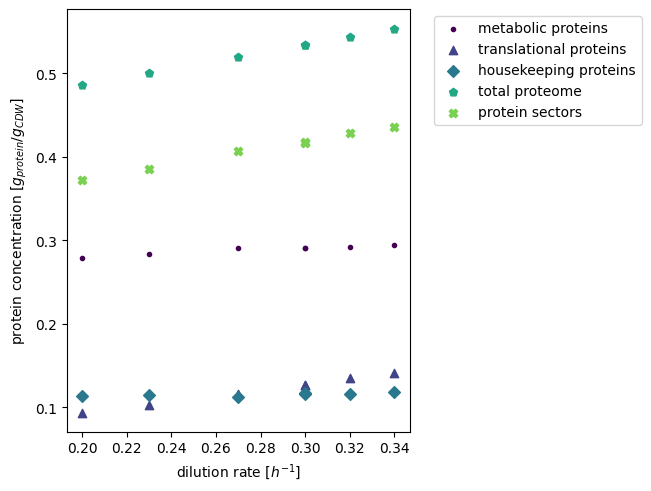

In [14]:

fig, ax = plt.subplots(constrained_layout= True)
dil_rates = protein_amounts.dilution_rate
#get colors for colorblind people
cmap = plt.get_cmap("viridis")
colors = [to_hex(cmap(i/(5))) for i in range(5)]

ax.scatter(dil_rates, protein_amounts.metabolic_protein, 
           marker = '.', label = 'metabolic proteins', color = colors[0])
ax.scatter(dil_rates, protein_amounts.translational_protein, 
           marker = '^', label = 'translational proteins', color = colors[1])
ax.scatter(dil_rates, protein_amounts.housekeeping_protein, 
           marker = 'D', label = 'housekeeping proteins', color = colors[2])
ax.scatter(dil_rates, protein_amounts.total_protein, 
           marker = 'p', label = 'total proteome', color = colors[3])
ax.scatter(dil_rates, protein_amounts.protein_sectors, 
           marker = 'X', label = 'protein sectors', color = colors[4])


ax.set_xlabel('dilution rate [$h^{-1}$]')
ax.set_ylabel('protein concentration [$g_{protein}/g_{CDW}$]')
plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')

Get the fit of protein sectors vs dilution rate

In [15]:
#to get most accurate results, use the fraction to calculate the intercept

slope_all_sectors, _ = perform_linear_regression(x=dil_rates, 
                                                     y=protein_amounts.protein_sectors)
_,intercept_all_sectors_fraction = perform_linear_regression(x=dil_rates, 
                                                      y= housekeeping_protein_fractions.sectors_protein_fraction)

intercept_all_sectors = intercept_all_sectors_fraction * get_g_protein_per_g_cdw(0)
print(f'all protein sectors occupy {intercept_all_sectors} g/g_cdw at zero growth and increase with {slope_all_sectors} g/g_cdw/h')

all protein sectors occupy 0.28697423725932236 g/g_cdw at zero growth and increase with 0.45431074007034344 g/g_cdw/h


## 7. Determine the relation between translational proteins and growth rate

In [16]:
slope_translation, _ = perform_linear_regression(x=dil_rates, 
                                                     y=protein_amounts.translational_protein)
_,intercept_translation_fraction = perform_linear_regression(x=dil_rates, 
                                                      y= housekeeping_protein_fractions.translational_protein_fraction)

intercept_translation = intercept_translation_fraction * get_g_protein_per_g_cdw(0)



# slope_translation, intercept_translation = perform_linear_regression(x=dil_rates, y=protein_amounts.translational_protein)
print(f'the translatioal protein sectors occupies {intercept_translation} g/g_cdw at zero growth and increase with {slope_translation} g/g_cdw/h')

the translatioal protein sectors occupies 0.039368389713352644 g/g_cdw at zero growth and increase with 0.34420838849848867 g/g_cdw/h


## 6. Determine unused enzymes at zero growth
Using pcYeast7.6 simulations of the effect of mCherry overproduction in SD (minimal) medium. The simulations fitted the data for other media well and SD medium was not analysed in the literature study by [Kafri et al. (2016)](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC4709330/).

In [17]:
#max mu determined by Narendranath et al. (2001) (https://academic.oup.com/jimb/article/26/3/171/5990600)
MAX_MU = 0.37 #[h-1] 

mcherry_overexpression = pd.read_excel(DATA_FILE_PATH, sheet_name='mcherry_overexpression').drop('Medium', axis=1)
mcherry_overexpression['mu'] = [MAX_MU*fitness/100 for fitness in mcherry_overexpression['Growth fitness']]
mcherry_overexpression['protein_g/g_CDW'] = [get_g_protein_per_g_cdw(row.mu)*row['Proteome fraction of mCherry'] for i, row in mcherry_overexpression.iterrows()]
mcherry_overexpression

,Proteome fraction of mCherry,Growth fitness,mu,protein_g/g_CDW
0,0.00,100.000000,0.370000,0.000000
1,0.01,98.254995,0.363543,0.005653
2,0.02,96.503410,0.357063,0.011242
3,0.03,94.767838,0.350641,0.016770
4,0.04,93.060688,0.344325,0.022237
5,0.05,91.369333,0.338067,0.027645
6,0.06,89.673634,0.331792,0.032991
7,0.08,86.292306,0.319282,0.043502
8,0.09,84.605951,0.313042,0.048668
9,0.10,82.924915,0.306822,0.053773


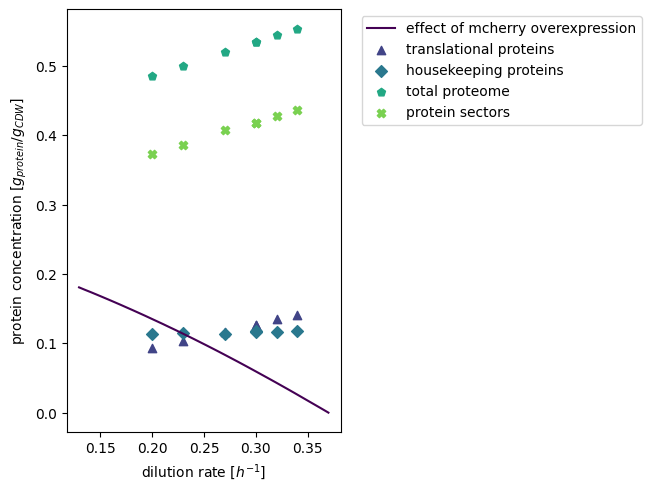

In [18]:
#plot the relation
fig, ax = plt.subplots(constrained_layout= True)
dil_rates = protein_amounts.dilution_rate
#get colors for colorblind people
cmap = plt.get_cmap("viridis")
colors = [to_hex(cmap(i/(5))) for i in range(5)]

ax.plot(mcherry_overexpression['mu'], mcherry_overexpression['protein_g/g_CDW'], 
           label = 'effect of mcherry overexpression', color = colors[0])
ax.scatter(dil_rates, protein_amounts.translational_protein, 
           marker = '^', label = 'translational proteins', color = colors[1])
ax.scatter(dil_rates, protein_amounts.housekeeping_protein, 
           marker = 'D', label = 'housekeeping proteins', color = colors[2])
ax.scatter(dil_rates, protein_amounts.total_protein, 
           marker = 'p', label = 'total proteome', color = colors[3])
ax.scatter(dil_rates, protein_amounts.protein_sectors, 
           marker = 'X', label = 'protein sectors', color = colors[4])


ax.set_xlabel('dilution rate [$h^{-1}$]')
ax.set_ylabel('protein concentration [$g_{protein}/g_{CDW}$]')
plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')

In [19]:
# get the intercept to determine the amount of unused proteins at 0 growth
slope, intercept = perform_linear_regression(x=mcherry_overexpression['mu'], y=mcherry_overexpression['Proteome fraction of mCherry'])

ups_intercept = get_g_protein_per_g_cdw(0)*intercept
ups_slope = -intercept/(MAX_MU*MAX_MU_INCREASE_AFTER_ALE)
# slope, intercept = perform_linear_regression(x=mcherry_overexpression['protein_g/g_CDW'], y=mcherry_overexpression['mu'])
print(slope)
print(f'the amount of usused proteins at zero growth is {ups_intercept} g/g_cdw, first estimate of slope is {ups_slope} g/g_cdw/h')

-1.664073864414664
the amount of usused proteins at zero growth is 0.23777971364078296 g/g_cdw, first estimate of slope is -1.0078664099430688 g/g_cdw/h


In [22]:
# Get the information about the enzyme sectors

unused_enzymes_df = pd.DataFrame({'Parameter': ['id_list', 'ups_0', 'ups_mu', 'mol_mass'],
                                        'Value': [BIOMASS_RXN_ID, ups_intercept, #*MEASURED_PROTEIN_FRACTION,
                                                  ups_slope, 1388.488*1e3], #*MEASURED_PROTEIN_FRACTION, 1388.488*1e3],
                                        'Unit': ['', 'g_p/g_cdw', 'g_p/g_cdw/h', '𝑔/𝑚𝑜𝑙'],
                                        'Description': ['biomass production rate', 'derived using Elsemman et al 2021 (Fig 1)',
                                                       'derived using Elsemman et al 2021 (Fig 1)',
                                                        'derived using Elsemman et al 2021 (Fig S10)']})

with pd.ExcelWriter(PAM_DATA_FILE_PATH, mode='a', engine='openpyxl', if_sheet_exists='replace') as writer:
    unused_enzymes_df.to_excel(writer, sheet_name='UnusedEnzyme', index =False)